# DATATHON 2026 — The Gridbreaker
## Notebook 01: Data Audit & Split

**Mục tiêu:** Hiểu cấu trúc dữ liệu, phát hiện bất thường, và tách tập Train/Validation trước khi phân tích sâu.

---

### Checklist Data Audit:
- Type & Cardinality
- Missing values & Duplicates
- PK/FK Integrity
- Data Leakage Check
- Target Distribution
- Time-based Split

---
## 1. Import & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 6), 'figure.dpi': 100, 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.labelsize': 12,
    'axes.spines.top': False, 'axes.spines.right': False,
})

COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#44BBA4',
          '#E94F37', '#393E41', '#5C946E', '#6B4C9A', '#D4A574']
sns.set_palette(sns.color_palette(COLORS))

def fmt_num(n):
    if pd.isna(n): return 'N/A'
    if abs(n) >= 1e9: return f'{n/1e9:.1f}B'
    elif abs(n) >= 1e6: return f'{n/1e6:.1f}M'
    elif abs(n) >= 1e3: return f'{n/1e3:.1f}K'
    return f'{n:,.0f}'

print('Import thành công!')

Import thành công!


---
## 2. Load Data & Overview

In [14]:
DATA_DIR = '../dataset/'

products = pd.read_csv(DATA_DIR + 'products.csv')
customers = pd.read_csv(DATA_DIR + 'customers.csv')
promotions = pd.read_csv(DATA_DIR + 'promotions.csv')
geography = pd.read_csv(DATA_DIR + 'geography.csv')
orders = pd.read_csv(DATA_DIR + 'orders.csv')
order_items = pd.read_csv(DATA_DIR + 'order_items.csv')
payments = pd.read_csv(DATA_DIR + 'payments.csv')
shipments = pd.read_csv(DATA_DIR + 'shipments.csv')
returns = pd.read_csv(DATA_DIR + 'returns.csv')
reviews = pd.read_csv(DATA_DIR + 'reviews.csv')
sales = pd.read_csv(DATA_DIR + 'sales.csv')
inventory = pd.read_csv(DATA_DIR + 'inventory.csv')
web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv')
sample_sub = pd.read_csv(DATA_DIR + 'sample_submission.csv')

# Parse dates
for df, cols in [(customers, ['signup_date']), (orders, ['order_date']),
                 (promotions, ['start_date','end_date']), (shipments, ['ship_date','delivery_date']),
                 (returns, ['return_date']), (reviews, ['review_date']),
                 (sales, ['Date']), (sample_sub, ['Date']),
                 (inventory, ['snapshot_date']), (web_traffic, ['date'])]:
    for c in cols:
        df[c] = pd.to_datetime(df[c])

datasets = {'products': products, 'customers': customers, 'promotions': promotions,
            'geography': geography, 'orders': orders, 'order_items': order_items,
            'payments': payments, 'shipments': shipments, 'returns': returns,
            'reviews': reviews, 'sales': sales, 'inventory': inventory, 'web_traffic': web_traffic}

print(f"{'Bảng':<20} {'Dòng':>10} {'Cột':>6} {'MB':>8}")
print("="*50)
for name, df in datasets.items():
    mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"{name:<20} {df.shape[0]:>10,} {df.shape[1]:>6} {mem:>7.1f}")

Bảng                       Dòng    Cột       MB
products                  2,412      8     0.7
customers               121,930      7    29.0
promotions                   50     10     0.0
geography                39,948      4     6.9
orders                  646,945      8   162.8
order_items             714,669      7    78.0
payments                646,945      4    50.6
shipments               566,067      4    17.3
returns                  39,939      7     6.1
reviews                 113,551      7    17.8
sales                     3,833      3     0.1
inventory                60,247     17    16.8
web_traffic               3,652      7     0.4


---
## 3. Type & Cardinality Audit

Kiểm tra kiểu dữ liệu, số lượng giá trị duy nhất, và phần trăm missing cho mỗi cột.

In [15]:
def audit_table(name, df):
    """Tạo bảng audit chi tiết cho một DataFrame."""
    audit = pd.DataFrame({
        'dtype': df.dtypes,
        'non_null': df.notnull().sum(),
        'null_count': df.isnull().sum(),
        'null_pct': (df.isnull().sum() / len(df) * 100).round(1),
        'nunique': df.nunique(),
        'sample_value': [df[c].dropna().iloc[0] if df[c].notnull().any() else 'N/A' for c in df.columns]
    })
    print(f"\n{'='*80}")
    print(f"{name.upper()} — {len(df):,} dòng × {len(df.columns)} cột")
    print(f"{'='*80}")
    display(audit)
    
    # Đánh dấu cardinality
    cat_cols = df.select_dtypes(include=['object']).columns
    if len(cat_cols) > 0:
        print(f"\n  Categorical columns cardinality:")
        for c in cat_cols:
            nuniq = df[c].nunique()
            label = 'HIGH' if nuniq > 50 else ('MEDIUM' if nuniq > 10 else 'LOW')
            print(f"    {c:<30} {nuniq:>8} unique [{label}]")

for name, df in datasets.items():
    audit_table(name, df)


PRODUCTS — 2,412 dòng × 8 cột


,dtype,non_null,null_count,null_pct,nunique,sample_value
product_id,int64,2412,0,0.0,2412,536
product_name,object,2412,0,0.0,2172,SaigonFlex UC-01
category,object,2412,0,0.0,4,Streetwear
segment,object,2412,0,0.0,8,Everyday
size,object,2412,0,0.0,4,S
color,object,2412,0,0.0,10,green
price,float64,2412,0,0.0,1990,11059.65
cogs,float64,2412,0,0.0,2381,9704.842875



  Categorical columns cardinality:
    product_name                       2172 unique [HIGH]
    category                              4 unique [LOW]
    segment                               8 unique [LOW]
    size                                  4 unique [LOW]
    color                                10 unique [LOW]

CUSTOMERS — 121,930 dòng × 7 cột


,dtype,non_null,null_count,null_pct,nunique,sample_value
customer_id,int64,121930,0,0.0,121930,1
zip,int64,121930,0,0.0,31491,15201
city,object,121930,0,0.0,42,Hai Phong
signup_date,datetime64[ns],121930,0,0.0,3941,2021-12-30 00:00:00
gender,object,121930,0,0.0,3,Female
age_group,object,121930,0,0.0,5,35-44
acquisition_channel,object,121930,0,0.0,6,social_media



  Categorical columns cardinality:
    city                                 42 unique [MEDIUM]
    gender                                3 unique [LOW]
    age_group                             5 unique [LOW]
    acquisition_channel                   6 unique [LOW]

PROMOTIONS — 50 dòng × 10 cột


...


INVENTORY — 60,247 dòng × 17 cột


,dtype,non_null,null_count,null_pct,nunique,sample_value
snapshot_date,datetime64[ns],60247,0,0.0,126,2022-10-31 00:00:00
product_id,int64,60247,0,0.0,1624,1
stock_on_hand,int64,60247,0,0.0,1895,3
units_received,int64,60247,0,0.0,360,1
units_sold,int64,60247,0,0.0,303,1
stockout_days,int64,60247,0,0.0,29,2
days_of_supply,float64,60247,0,0.0,9289,90.0
fill_rate,float64,60247,0,0.0,29,0.9333
stockout_flag,int64,60247,0,0.0,2,1
overstock_flag,int64,60247,0,0.0,2,0



  Categorical columns cardinality:
    product_name                       1465 unique [HIGH]
    category                              4 unique [LOW]
    segment                               8 unique [LOW]

WEB_TRAFFIC — 3,652 dòng × 7 cột


,dtype,non_null,null_count,null_pct,nunique,sample_value
date,datetime64[ns],3652,0,0.0,3652,2013-01-01 00:00:00
sessions,int64,3652,0,0.0,3447,9760
unique_visitors,int64,3652,0,0.0,3382,7253
page_views,int64,3652,0,0.0,3620,39093
bounce_rate,float64,3652,0,0.0,261,0.00514
avg_session_duration_sec,float64,3652,0,0.0,1771,102.9
traffic_source,object,3652,0,0.0,6,organic_search



  Categorical columns cardinality:
    traffic_source                        6 unique [LOW]


---
## 4. Missing Values Analysis

GIÁ TRỊ THIẾU (MISSING VALUES)

  promotions:
     applicable_category             40 (80.00%)

  order_items:
     promo_id                   438,353 (61.34%)
     promo_id_2                 714,463 (99.97%)


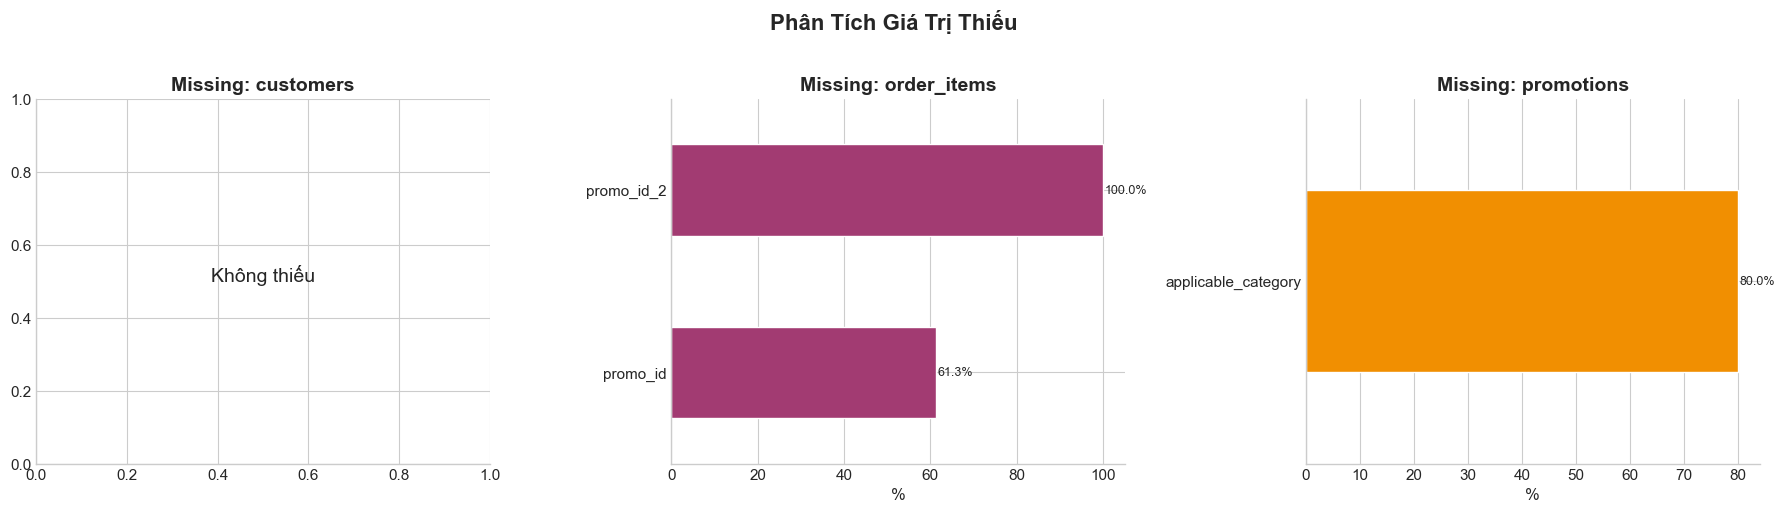

In [23]:
print("GIÁ TRỊ THIẾU (MISSING VALUES)")
print("="*55)
for name, df in datasets.items():
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if len(miss) > 0:
        print(f"\n  {name}:")
        for col, cnt in miss.items():
            print(f"     {col:<25} {cnt:>8,} ({cnt/len(df)*100:.2f}%)")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, df) in enumerate([('customers', customers), ('order_items', order_items), ('promotions', promotions)]):
    miss_pct = (df.isnull().sum() / len(df) * 100).sort_values()
    miss_pct = miss_pct[miss_pct > 0]
    if len(miss_pct) > 0:
        miss_pct.plot(kind='barh', ax=axes[idx], color=COLORS[idx], edgecolor='white')
        axes[idx].set_title(f'Missing: {name}', fontweight='bold')
        axes[idx].set_xlabel('%')
        for i, v in enumerate(miss_pct):
            axes[idx].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
    else:
        axes[idx].text(0.5, 0.5, 'Không thiếu', transform=axes[idx].transAxes, ha='center', fontsize=14)
        axes[idx].set_title(f'Missing: {name}', fontweight='bold')
plt.suptitle('Phân Tích Giá Trị Thiếu', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Kết luận Missing Values

- **Descriptive:** Missing tập trung ở demographics (`gender`, `age_group`) và promo fields (`promo_id`, `promo_id_2`, `applicable_category`)
- **Diagnostic:** Các trường nullable này do thiết kế nghiệp vụ — thu thập không bắt buộc (demographics) hoặc đơn hàng không áp dụng khuyến mãi (promo fields). `promo_id_2` gần 100% null → khả năng cao là trường dự phòng chưa dùng.
- **Prescriptive:** Dùng `'Unknown'` cho demographics thay vì drop rows. Cân nhắc loại bỏ `promo_id_2` nếu không có giá trị phân tích.

---
## 5. Duplicate & PK/FK Integrity Check

In [17]:
# 5.1 Primary Key Uniqueness
print("KIỂM TRA KHÓA CHÍNH (PRIMARY KEY)")
print("="*55)
for name, pk, df in [('products','product_id',products), ('customers','customer_id',customers),
                      ('orders','order_id',orders), ('payments','order_id',payments),
                      ('geography','zip',geography), ('returns','return_id',returns),
                      ('reviews','review_id',reviews)]:
    dups = len(df) - df[pk].nunique()
    print(f"{name}.{pk}: {len(df):,} rows, {dups} duplicates")

print(f"\nKIỂM TRA KHÓA NGOẠI (FOREIGN KEY)")
print("="*55)
for fk_n, fk_v, pk_n, pk_v in [
    ('orders.customer_id', orders['customer_id'], 'customers.customer_id', customers['customer_id']),
    ('order_items.order_id', order_items['order_id'], 'orders.order_id', orders['order_id']),
    ('order_items.product_id', order_items['product_id'], 'products.product_id', products['product_id']),
    ('payments.order_id', payments['order_id'], 'orders.order_id', orders['order_id']),
    ('returns.order_id', returns['order_id'], 'orders.order_id', orders['order_id']),
    ('reviews.order_id', reviews['order_id'], 'orders.order_id', orders['order_id'])]:
    orphans = fk_v[~fk_v.isin(pk_v)].nunique()
    print(f" {fk_n} → {pk_n} | orphans: {orphans}")

KIỂM TRA KHÓA CHÍNH (PRIMARY KEY)
products.product_id: 2,412 rows, 0 duplicates
customers.customer_id: 121,930 rows, 0 duplicates
orders.order_id: 646,945 rows, 0 duplicates
payments.order_id: 646,945 rows, 0 duplicates
geography.zip: 39,948 rows, 0 duplicates
returns.return_id: 39,939 rows, 0 duplicates
reviews.review_id: 113,551 rows, 0 duplicates

KIỂM TRA KHÓA NGOẠI (FOREIGN KEY)
 orders.customer_id → customers.customer_id | orphans: 0
 order_items.order_id → orders.order_id | orphans: 0
 order_items.product_id → products.product_id | orphans: 0
 payments.order_id → orders.order_id | orphans: 0
 returns.order_id → orders.order_id | orphans: 0
 reviews.order_id → orders.order_id | orphans: 0


In [18]:
# 5.2 Full Duplicate Rows Check
print("\nKIỂM TRA DÒNG TRÙNG LẶP HOÀN TOÀN")
print("="*55)
for name, df in datasets.items():
    dup_count = df.duplicated().sum()
    status = f'{dup_count} dòng trùng'
    print(f"  {name:<20} {status}")


KIỂM TRA DÒNG TRÙNG LẶP HOÀN TOÀN
  products             0 dòng trùng
  customers            0 dòng trùng
  promotions           0 dòng trùng
  geography            0 dòng trùng
  orders               0 dòng trùng
  order_items          0 dòng trùng
  payments             0 dòng trùng
  shipments            0 dòng trùng
  returns              0 dòng trùng
  reviews              0 dòng trùng
  sales                0 dòng trùng
  inventory            0 dòng trùng
  web_traffic          0 dòng trùng


### Kết luận PK/FK & Duplicates

- **Descriptive:** Tất cả Primary Keys đều unique (không trùng). Tất cả Foreign Keys đều hợp lệ (không có orphan records).
- **Diagnostic:** Dữ liệu đã được thiết kế tốt, đảm bảo referential integrity hoàn chỉnh.
- **Prescriptive:** Có thể join các bảng một cách an toàn mà không lo mất dữ liệu.

---
## 6. Data Leakage Check

Kiểm tra các vấn đề về leakage cho Sales Forecasting: thứ tự thời gian, features từ tương lai.

In [24]:
print("KIỂM TRA TEMPORAL CONSISTENCY (Thứ tự thời gian)")
print("="*60)

# 6.1 ship_date >= order_date?
ship_orders = shipments.merge(orders[['order_id','order_date']], on='order_id', how='left')
bad_ship = (ship_orders['ship_date'] < ship_orders['order_date']).sum()
print(f"  Shipments trước Order date:  {bad_ship} {'(Đúng)' if bad_ship == 0 else '(Sai)'}")

# 6.2 delivery_date >= ship_date?
bad_delivery = (ship_orders['delivery_date'] < ship_orders['ship_date']).sum()
print(f"  Delivery trước Ship date:    {bad_delivery} {'(Đúng)' if bad_delivery == 0 else '(Sai)'}")

# 6.3 return_date >= order_date?
ret_orders = returns.merge(orders[['order_id','order_date']], on='order_id', how='left')
bad_return = (ret_orders['return_date'] < ret_orders['order_date']).sum()
print(f"  Return trước Order date:     {bad_return} {'(Đúng)' if bad_return == 0 else '(Sai)'}")

# 6.4 review_date >= order_date?
rev_orders = reviews.merge(orders[['order_id','order_date']], on='order_id', how='left')
bad_review = (rev_orders['review_date'] < rev_orders['order_date']).sum()
print(f"  Review trước Order date:     {bad_review} {'(Đúng)' if bad_review == 0 else '(Sai)'}")

# 6.5 Khoảng thời gian giữa các bước
print(f"\nKHOẢNG THỜI GIAN TRUNG BÌNH GIỮA CÁC BƯỚC")
print("-"*60)
avg_ship_time = (ship_orders['ship_date'] - ship_orders['order_date']).dt.days.describe()
print(f"  Order → Ship (ngày):")
print(f"    Mean: {avg_ship_time['mean']:.1f}, Median: {avg_ship_time['50%']:.1f}, Max: {avg_ship_time['max']:.0f}")

avg_deliver_time = (ship_orders['delivery_date'] - ship_orders['ship_date']).dt.days.describe()
print(f"  Ship → Delivery (ngày):")
print(f"    Mean: {avg_deliver_time['mean']:.1f}, Median: {avg_deliver_time['50%']:.1f}, Max: {avg_deliver_time['max']:.0f}")

avg_return_time = (ret_orders['return_date'] - ret_orders['order_date']).dt.days.describe()
print(f"  Order → Return (ngày):")
print(f"    Mean: {avg_return_time['mean']:.1f}, Median: {avg_return_time['50%']:.1f}, Max: {avg_return_time['max']:.0f}")

KIỂM TRA TEMPORAL CONSISTENCY (Thứ tự thời gian)
  Shipments trước Order date:  0 (Đúng)
  Delivery trước Ship date:    0 (Đúng)
  Return trước Order date:     0 (Đúng)
  Review trước Order date:     0 (Đúng)

KHOẢNG THỜI GIAN TRUNG BÌNH GIỮA CÁC BƯỚC
------------------------------------------------------------
  Order → Ship (ngày):
    Mean: 1.5, Median: 1.0, Max: 3
  Ship → Delivery (ngày):
    Mean: 4.5, Median: 4.0, Max: 7
  Order → Return (ngày):
    Mean: 18.0, Median: 18.0, Max: 31


# 6.6 Xác định features có nguy cơ leakage cho forecasting
CẢNH BÁO LEAKAGE CHO SALES FORECASTING

Khi dự báo Revenue tại ngày t, KHÔNG được dùng thông tin sau:

- Revenue/COGS của ngày t (target variable)
- order_status (chỉ biết sau khi đơn hoàn thành)
- delivery_date (chỉ biết sau khi giao hàng)
- return_date, return_reason (chỉ biết sau khi trả hàng)
- review_date, rating (chỉ biết sau khi đánh giá)

CÓ THỂ dùng (với lag phù hợp):
- Revenue/COGS quá khứ (lag ≥ 1 ngày)
- order_date, order_count quá khứ
- web_traffic quá khứ (sessions, bounce_rate)
- promotion schedule (biết trước)
- inventory snapshot cuối tháng trước
- calendar features (day_of_week, month, holiday...)


### Kết luận Data Leakage

- **Descriptive:** Thứ tự thời gian trong dữ liệu nhất quán — không có shipment/return/review nào xảy ra trước ngày đặt hàng.
- **Diagnostic:** Dữ liệu đáng tin cậy về mặt temporal. Khoảng thời gian O→S→D hợp lý với nghiệp vụ TMĐT.
- **Prescriptive:** Khi xây dựng features cho forecasting, phải tuân thủ nghiêm ngặt quy tắc: chỉ dùng thông tin **đã có tại thời điểm dự báo** (past data with proper lag).

---
## 7. Target Variable Distribution

Phân tích phân bố Revenue (target) — chuẩn bị cho bước Univariate EDA sâu hơn ở Notebook 02.

TARGET VARIABLE: Revenue
  Khoảng thời gian:   2012-07-04 → 2022-12-31
  Số ngày:            3,833
  Revenue min:        279,814
  Revenue max:        20,905,271
  Revenue mean:       4,286,584
  Revenue median:     3,647,304
  Revenue std:        2,624,840
  Ngày revenue ≤ 0:   0


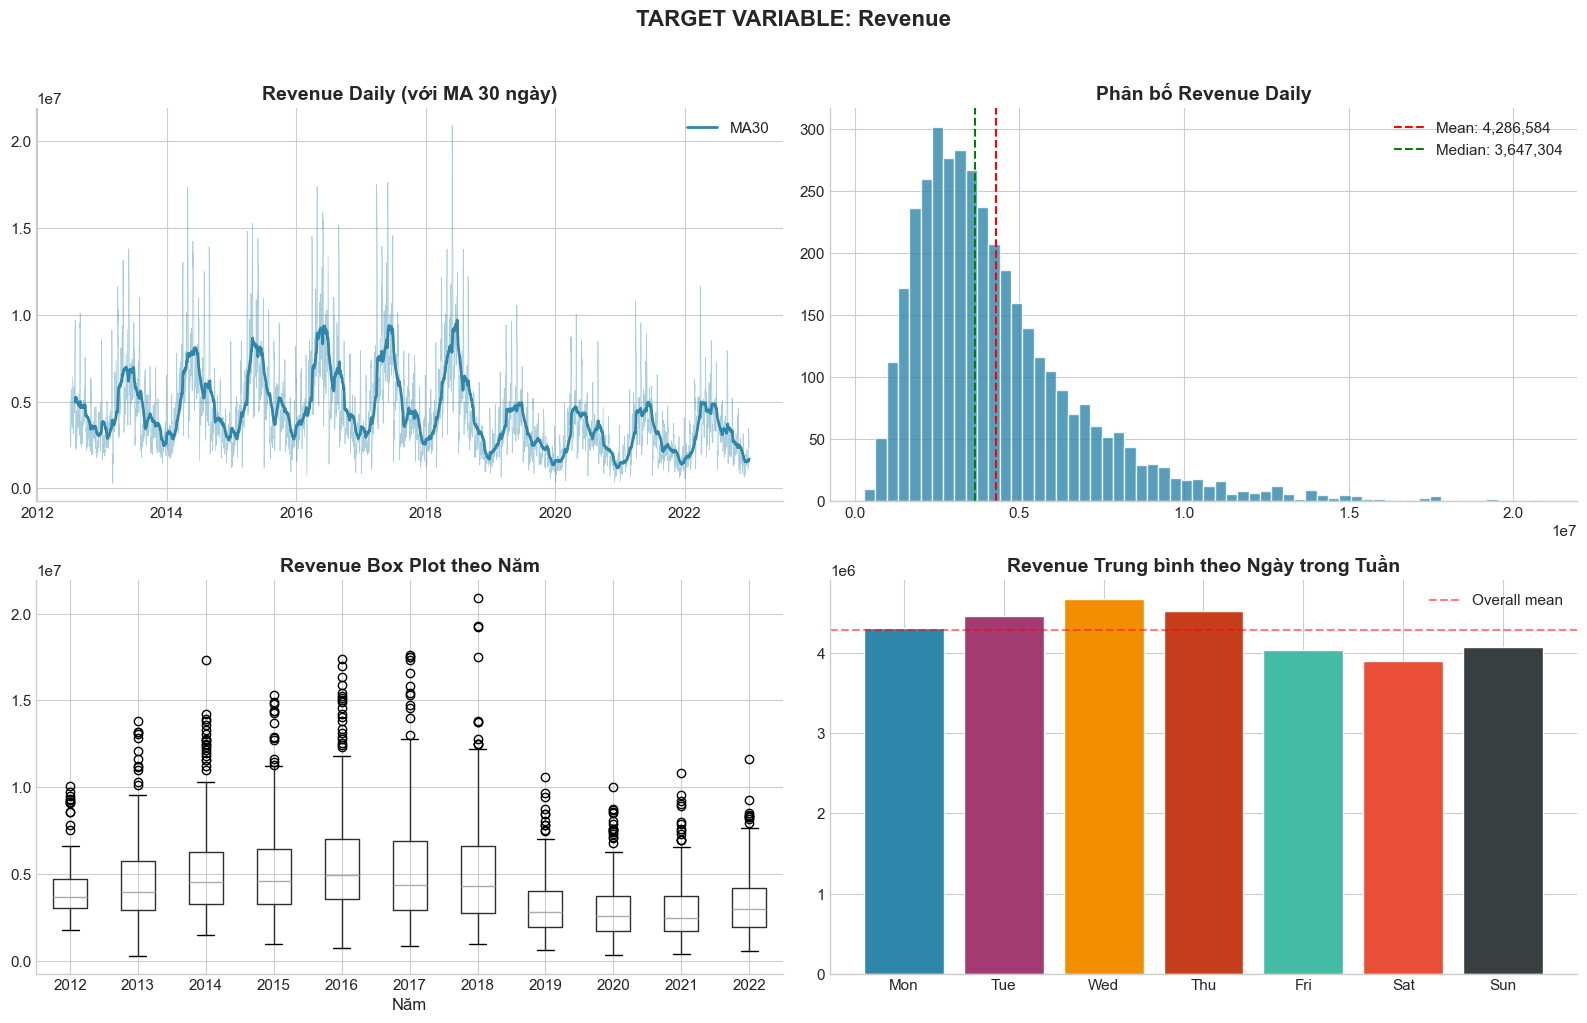

In [20]:
print("TARGET VARIABLE: Revenue")
print("="*55)
print(f"  Khoảng thời gian:   {sales['Date'].min().date()} → {sales['Date'].max().date()}")
print(f"  Số ngày:            {len(sales):,}")
print(f"  Revenue min:        {sales['Revenue'].min():,.0f}")
print(f"  Revenue max:        {sales['Revenue'].max():,.0f}")
print(f"  Revenue mean:       {sales['Revenue'].mean():,.0f}")
print(f"  Revenue median:     {sales['Revenue'].median():,.0f}")
print(f"  Revenue std:        {sales['Revenue'].std():,.0f}")
print(f"  Ngày revenue ≤ 0:   {(sales['Revenue'] <= 0).sum()}")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 7.1 Time Series
axes[0,0].plot(sales['Date'], sales['Revenue'], alpha=0.4, color=COLORS[0], linewidth=0.5)
axes[0,0].plot(sales['Date'], sales['Revenue'].rolling(30).mean(), color=COLORS[0], linewidth=2, label='MA30')
axes[0,0].set_title('Revenue Daily (với MA 30 ngày)')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0,0].legend()

# 7.2 Histogram
axes[0,1].hist(sales['Revenue'], bins=60, color=COLORS[0], edgecolor='white', alpha=0.8)
axes[0,1].axvline(sales['Revenue'].mean(), color='red', linestyle='--', label=f'Mean: {sales["Revenue"].mean():,.0f}')
axes[0,1].axvline(sales['Revenue'].median(), color='green', linestyle='--', label=f'Median: {sales["Revenue"].median():,.0f}')
axes[0,1].set_title('Phân bố Revenue Daily')
axes[0,1].legend()

# 7.3 Box plot theo Year
sales['year'] = sales['Date'].dt.year
sales.boxplot(column='Revenue', by='year', ax=axes[1,0])
axes[1,0].set_title('Revenue Box Plot theo Năm')
axes[1,0].set_xlabel('Năm')
plt.sca(axes[1,0])
plt.title('Revenue Box Plot theo Năm')

# 7.4 Revenue theo Day of Week
sales['dow'] = sales['Date'].dt.dayofweek
dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_rev = sales.groupby('dow')['Revenue'].mean()
axes[1,1].bar(dow_names, dow_rev.values, color=COLORS[:7], edgecolor='white')
axes[1,1].axhline(sales['Revenue'].mean(), color='red', linestyle='--', alpha=0.5, label='Overall mean')
axes[1,1].set_title('Revenue Trung bình theo Ngày trong Tuần')
axes[1,1].legend()

plt.suptitle('TARGET VARIABLE: Revenue', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Kết luận Target Distribution

- **Descriptive:** Revenue daily có trend tăng theo thời gian, phân bố lệch phải (right-skewed), và có seasonality rõ ràng theo ngày trong tuần.
- **Diagnostic:** Phân bố lệch phải gợi ý có thể cần log-transform khi modeling. Sự khác biệt Revenue theo day-of-week cho thấy calendar features sẽ rất quan trọng.
- **Predictive:** Trend tăng và seasonality rõ → SARIMA/Prophet sẽ bắt được pattern tốt. Các ngày cuối tuần có revenue patterns riêng.
- **Prescriptive:** Cần phân tích Stationarity và ACF/PACF chi tiết ở Notebook 02 để xác định order cho ARIMA models.

---
## 8. Time-based Data Split

**Quan trọng:** Trong time-series forecasting, PHẢI dùng time-based split (không random split) để tránh data leakage.

TIME-BASED DATA SPLIT
  TRAIN:      2012-07-04 → 2021-12-31 | 3,468 ngày
  VALIDATION: 2022-01-01 → 2022-12-31 | 365 ngày
  TEST:       2023-01-01 → 2024-07-01 | 548 ngày

  Train Revenue:
    Mean: 4,400,441 | Std: 2,680,300
  Validation Revenue:
    Mean: 3,204,791 | Std: 1,676,108


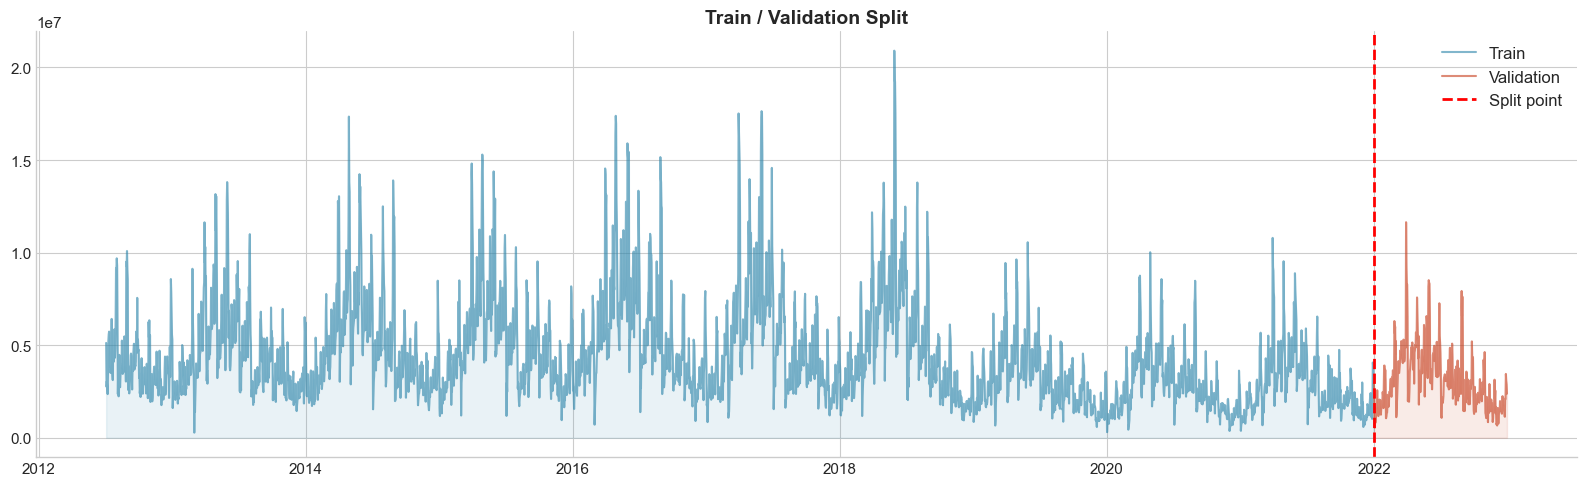


LƯU Ý QUAN TRỌNG:
  → Từ các notebook tiếp theo, TẤT CẢ phân tích EDA sẽ dùng dữ liệu Train
  → Validation set chỉ dùng để đánh giá model ở bước cuối
  → Test set (2023-2024) KHÔNG ĐƯỢC sử dụng trong bất kỳ bước phân tích nào


In [21]:
# Định nghĩa ranh giới thời gian
TRAIN_END = '2021-12-31'
VAL_START = '2022-01-01'
VAL_END = '2022-12-31'
TEST_START = '2023-01-01'  # Dùng sample_submission

# Split sales data
sales_train = sales[sales['Date'] <= TRAIN_END].copy()
sales_val = sales[(sales['Date'] >= VAL_START) & (sales['Date'] <= VAL_END)].copy()

print("TIME-BASED DATA SPLIT")
print("="*55)
print(f"  TRAIN:      {sales_train['Date'].min().date()} → {sales_train['Date'].max().date()} | {len(sales_train):,} ngày")
print(f"  VALIDATION: {sales_val['Date'].min().date()} → {sales_val['Date'].max().date()} | {len(sales_val):,} ngày")
print(f"  TEST:       {sample_sub['Date'].min().date()} → {sample_sub['Date'].max().date()} | {len(sample_sub):,} ngày")

print(f"\n  Train Revenue:")
print(f"    Mean: {sales_train['Revenue'].mean():,.0f} | Std: {sales_train['Revenue'].std():,.0f}")
print(f"  Validation Revenue:")
print(f"    Mean: {sales_val['Revenue'].mean():,.0f} | Std: {sales_val['Revenue'].std():,.0f}")

# Visualization
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(sales_train['Date'], sales_train['Revenue'], label='Train', color=COLORS[0], alpha=0.6)
ax.plot(sales_val['Date'], sales_val['Revenue'], label='Validation', color=COLORS[3], alpha=0.6)
ax.axvline(pd.to_datetime(VAL_START), color='red', linestyle='--', linewidth=2, label='Split point')
ax.fill_between(sales_train['Date'], 0, sales_train['Revenue'], alpha=0.1, color=COLORS[0])
ax.fill_between(sales_val['Date'], 0, sales_val['Revenue'], alpha=0.1, color=COLORS[3])
ax.set_title('Train / Validation Split', fontweight='bold', fontsize=14)
ax.legend(fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print("\nLƯU Ý QUAN TRỌNG:")
print("  → Từ các notebook tiếp theo, TẤT CẢ phân tích EDA sẽ dùng dữ liệu Train")
print("  → Validation set chỉ dùng để đánh giá model ở bước cuối")
print("  → Test set (2023-2024) KHÔNG ĐƯỢC sử dụng trong bất kỳ bước phân tích nào")

---
## Tổng kết Notebook 01

| Hạng mục | Kết quả |
|---|---|
| **Bảng dữ liệu** | 13 bảng, quan hệ PK/FK hoàn chỉnh |
| **Missing values** | Tập trung ở demographics (nullable by design) và promo fields |
| **Duplicates** | Không có PK duplicate, không có full-row duplicate |
| **Leakage** | Temporal consistency — cần cẩn thận khi tạo features từ delivery/return/review |
| **Target (Revenue)** | Trend tăng, right-skewed, seasonality theo DOW |
| **Data Split** | Train: →2021 / Val: 2022 / Test: 2023-2024 |

